# Finance RAG v2 — FinanceBench (ICAIF-24)

Изменения относительно v1:
- reranker `BAAI/bge-reranker-v2-m3`
- в генерацию 5–7 пассажей
- MODE: exact / inferred / insufficient
- confidence score (retrieval + LLM)

Данные в `data/`: `corpus.jsonl`, `queries.jsonl`, `FinanceBench_qrels.tsv`.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils import set_seed, RANDOM_STATE, write_jsonl
from src.data_loader import load_financebench, doc_text
from src.pipeline import RetrievalPipeline
from src.evaluate import evaluate_retrieval, print_metrics
from src.generate import generate_answer, format_answer
from src.rerank import DEFAULT_RERANKER

set_seed(RANDOM_STATE)
DATA_DIR = ROOT / 'data'
RESULTS_DIR = ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)
print('ROOT =', ROOT)
print('default reranker:', DEFAULT_RERANKER)


ROOT = d:\Projects_ML\FinanceRAG\finance_rag_v2
default reranker: BAAI/bge-reranker-v2-m3


## 1. Load data

In [2]:
corpus, queries, qrels = load_financebench(DATA_DIR)

print(f'corpus:  {len(corpus)} docs')
print(f'queries: {len(queries)}')
print(f'qrels:   {len(qrels)} queries with labels')
print(f'queries ∩ qrels: {sum(1 for q in queries if q in qrels)}')

qid0 = next(iter(queries))
print('\nSample Q:', queries[qid0][:240])


corpus:  180 docs
queries: 150
qrels:   45 queries with labels
queries ∩ qrels: 45

Sample Q: What is the FY2019 - FY2020 total revenue growth rate for Block (formerly known as Square)? Answer in units of percents and round to one decimal place. Approach the question asked by assuming the standpoint of an investment banking analyst 


## 2. Build indexes (v2)

Reranker включён по умолчанию. Первый прогон скачает `bge-reranker-v2-m3` — это дольше MiniLM.

In [ ]:
pipe = RetrievalPipeline(
    corpus,
    dense_model='sentence-transformers/all-MiniLM-L6-v2',
    use_reranker=True,
    reranker_model=DEFAULT_RERANKER,  # BAAI/bge-reranker-v2-m3
)
print('dense backend:', pipe.dense._backend)
print('reranker:', None if pipe.reranker is None else pipe.reranker.model_name)


## 3. Retrieval comparison

Сравниваем bm25 / dense / hybrid / hybrid+rerank.
`rerank_top_k=7` — сколько документов отдаём дальше в генерацию.

In [4]:
MAX_QUERIES = None  # например 30 для быстрого прогона

eval_queries = queries
if MAX_QUERIES is not None:
    eval_queries = dict(list(queries.items())[:MAX_QUERIES])

# сохраняем reranker, чтобы точечно выключать
_ce = pipe.reranker

configs = {
    'bm25': dict(mode='bm25', use_ce=False),
    'dense': dict(mode='dense', use_ce=False),
    'hybrid': dict(mode='hybrid', use_ce=False),
    'hybrid+rerank': dict(mode='hybrid', use_ce=True),
}

all_results = {}
metrics_table = {}

for name, cfg in configs.items():
    print(f'\n=== {name} ===')
    pipe.reranker = _ce if cfg['use_ce'] else None
    res = pipe.retrieve_many(
        eval_queries,
        mode=cfg['mode'],
        top_k=50,
        rerank_top_k=7,
        fusion='rrf',
    )
    all_results[name] = res
    qrels_sub = {q: qrels[q] for q in res if q in qrels}
    m = evaluate_retrieval(res, qrels_sub, k_values=[5, 10])
    metrics_table[name] = m
    print_metrics(name, m)

pipe.reranker = _ce



=== bm25 ===
  retrieve 20/150
  retrieve 40/150
  retrieve 60/150
  retrieve 80/150
  retrieve 100/150
  retrieve 120/150
  retrieve 140/150
  retrieve 150/150
bm25:
  ndcg@5: 0.2010
  recall@5: 0.2444
  mrr@5: 0.2026
  ndcg@10: 0.2055
  recall@10: 0.2556
  mrr@10: 0.2058

=== dense ===
  retrieve 20/150
  retrieve 40/150
  retrieve 60/150
  retrieve 80/150
  retrieve 100/150
  retrieve 120/150
  retrieve 140/150
  retrieve 150/150
dense:
  ndcg@5: 0.7193
  recall@5: 0.9222
  mrr@5: 0.6785
  ndcg@10: 0.7241
  recall@10: 0.9333
  mrr@10: 0.6785

=== hybrid ===
  retrieve 20/150
  retrieve 40/150
  retrieve 60/150
  retrieve 80/150
  retrieve 100/150
  retrieve 120/150
  retrieve 140/150
  retrieve 150/150
hybrid:
  ndcg@5: 0.4642
  recall@5: 0.6222
  mrr@5: 0.4233
  ndcg@10: 0.4849
  recall@10: 0.6778
  mrr@10: 0.4344

=== hybrid+rerank ===
  retrieve 20/150
  retrieve 40/150
  retrieve 60/150
  retrieve 80/150
  retrieve 100/150
  retrieve 120/150
  retrieve 140/150
  retrieve 150/15

               ndcg@5  recall@5   mrr@5  ndcg@10  recall@10  mrr@10
hybrid+rerank  0.8586    0.9444  0.8478   0.8660     0.9667  0.8510
dense          0.7193    0.9222  0.6785   0.7241     0.9333  0.6785
hybrid         0.4642    0.6222  0.4233   0.4849     0.6778  0.4344
bm25           0.2010    0.2444  0.2026   0.2055     0.2556  0.2058


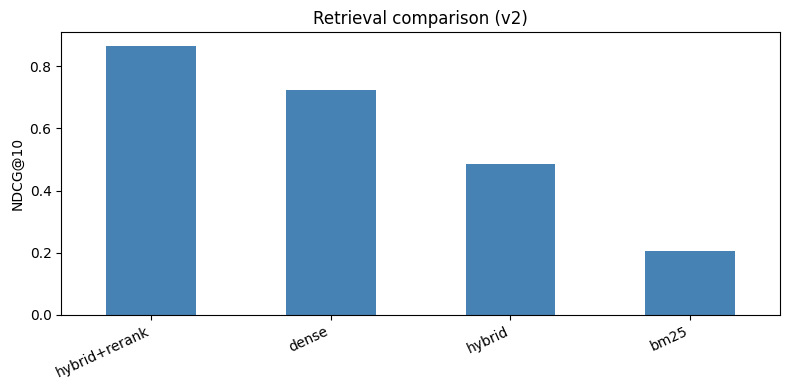

In [5]:
df_m = pd.DataFrame(metrics_table).T.round(4)
df_m = df_m.sort_values('ndcg@10', ascending=False)
print(df_m.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
df_m['ndcg@10'].plot.bar(ax=ax, color='steelblue')
ax.set_ylabel('NDCG@10')
ax.set_title('Retrieval comparison (v2)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


## 4. Generation with confidence (v2)

Для каждого вопроса:
- top-7 чанков после hybrid+rerank
- structured answer + CONFIDENCE
- если факта нет — FOUND + inference, а не выдуманная цифра


In [6]:
best_method = df_m.index[0]
print('Best retrieval method:', best_method)

# 5 запросов из qrels (или меньше, если набор маленький)
sample_qids = [q for q in eval_queries if q in qrels][:5]

gen_rows = []
for qid in sample_qids:
    qtext = queries[qid]
    hits = all_results[best_method][qid]

    print('\n' + '=' * 72)
    print('Q:', qtext)

    out = generate_answer(
        qtext,
        hits,
        corpus,
        backend='auto',
        max_passages=7,  # v2: 5–7
    )
    print(format_answer(out))

    gen_rows.append({
        'query_id': qid,
        'query': qtext,
        'answer': out.get('answer'),
        'mode': out.get('mode'),
        'confidence': out.get('confidence'),
        'retrieval_confidence': out.get('retrieval_confidence'),
        'llm_confidence': out.get('llm_confidence'),
        'found': out.get('found'),
        'reasoning': out.get('reasoning'),
        'sources': out.get('source_ids'),
        'backend': out.get('backend'),
    })


Best retrieval method: hybrid+rerank

Q: How does Boeing's effective tax rate in FY2022 compare to FY2021?
MODE: exact
CONFIDENCE: 0.553 (retrieval=0.107, llm=0.85)
BACKEND: ollama:llama3.1

Boeing's effective tax rate decreased from FY2021 to FY2022.

FOUND:
• The effective tax rate for FY2022 was 21.6% [3].
• The effective tax rate for FY2021 was 24.6% [3].

SOURCES:
dd2acffb6, dd2acf0f2, dd2ac410c, dd2ace5a8, dd2ac6718, dd2acdc52, dd2acf692

Q: What is the amount of the gain accruing to JnJ as a result of the separation of its Consumer Health business segment, as of August 30, 2023?
MODE: insufficient
CONFIDENCE: 0.2 (retrieval=0.499, llm=0.0)
BACKEND: ollama:llama3.1

The exact figure for the gain accruing to JNJ from the separation of its Consumer Health business segment is missing.

FOUND:
* No mention of a specific gain amount related to the separation of the Consumer Health business segment.
* Passage [1] mentions that Johnson & Johnson secured $13.2 billion in cash proceeds fr

In [ ]:
# сохранение
write_jsonl(RESULTS_DIR / 'generation_samples_v2.jsonl', gen_rows)

for name, res in all_results.items():
    rows = []
    for qid, hits in res.items():
        for rank, (did, score) in enumerate(hits, start=1):
            rows.append({
                'query_id': qid,
                'corpus_id': did,
                'score': score,
                'rank': rank,
            })
    pd.DataFrame(rows).to_csv(RESULTS_DIR / f'retrieval_{name}_v2.csv', index=False)

print('saved under', RESULTS_DIR)
if gen_rows:
    confs = [r['confidence'] for r in gen_rows if r.get('confidence') is not None]
    print('mean confidence on samples:', round(sum(confs) / len(confs), 3) if confs else 'n/a')
    print('modes:', {m: sum(1 for r in gen_rows if r.get('mode') == m) for m in ('exact', 'inferred', 'insufficient')})


## 5. Выводы (v2)

- `bge-reranker-v2-m3` обычно лучше ms-marco MiniLM на top-10, но тяжелее по памяти/времени.
- 7 пассажей в контексте снижают шанс «не нашли», ценой шума — confidence как раз для этого.
- MODE=inferred полезен на вопросах вроде spin-off / gain on disposal, где цифра может быть размазана по нескольким секциям.
- Низкий confidence (<0.5) — сигнал не использовать ответ как факт без ручной проверки.

### Ещё можно
- bge-base embeddings вместо MiniLM
- query expansion под ticker + event (divestiture, impairment)
- RAGAS на gen_rows
- кэш индекса